In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    load_iris, load_wine, load_breast_cancer,
    make_classification, make_regression, make_moons
)
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error,
    log_loss, roc_auc_score, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.precision', 4)

def plot_decision_boundary(model, X, y, title, step=0.04):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step)
    )
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=35)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.tight_layout()
    plt.show()

print('Setup completed successfully.')

Setup completed successfully.


# Part A — Theoretical Questions

## Question 1: What is a Support Vector Machine (SVM)?


### 📌 Definition
A **Support Vector Machine** is a supervised algorithm used mainly for classification and also for regression. It finds a decision boundary called a **hyperplane** that separates classes with the largest possible margin.

### Working principle
1. Represent observations in feature space.
2. Consider possible separating hyperplanes.
3. Measure each hyperplane's distance from the nearest points.
4. Choose the maximum-margin hyperplane.
5. Classify new observations according to the side of the boundary.

The closest points are **support vectors** and determine the boundary.

### Example
Using suspicious-word count and link count, SVM can separate spam from normal emails.

### ✅ Advantages
Effective in high-dimensional spaces, supports nonlinear kernels, and often performs well on small-to-medium datasets.

### ⚠️ Disadvantages
Needs scaling and parameter tuning, can be slow on very large datasets, and is less interpretable than simple linear models.

### Summary
SVM creates a robust boundary by maximizing separation between classes.

## Question 2: Difference between Hard Margin and Soft Margin SVM


| Aspect | Hard Margin | Soft Margin |
|---|---|---|
| Errors | Not allowed | Some allowed |
| Data | Perfectly separable | Noisy/overlapping |
| Slack variables | No | Yes, $\xi_i$ |
| Outlier sensitivity | Very high | Lower |
| Practical use | Rare | Common |

Hard margin requires $y_i(w^Tx_i+b)\ge1$. Soft margin uses $y_i(w^Tx_i+b)\ge1-\xi_i$ and minimizes

$$\frac12\|w\|^2+C\sum_i\xi_i$$

A small `C` tolerates more violations; a large `C` penalizes them strongly.

### Example
Medical classes often overlap, so soft margin is more realistic.

### Summary
Hard margin demands perfect separation; soft margin balances margin width and errors.

## Question 3: Mathematical intuition behind SVM


The separating hyperplane is $w^Tx+b=0$. Supporting planes are $w^Tx+b=1$ and $w^Tx+b=-1$.

The margin width is:

$$\frac{2}{\|w\|}$$

Therefore, maximizing margin is equivalent to minimizing $\frac12\|w\|^2$ subject to $y_i(w^Tx_i+b)\ge1$.

For noisy data, slack variables and `C` are added.

### Intuition
A smaller $\|w\|$ gives a wider margin. Points far from the margin have little effect. Points on or inside it become support vectors.

### Example
Among several separating lines, SVM chooses the one farthest from the nearest points of both classes.

### Summary
SVM is a constrained optimization problem designed to maximize geometric separation.

## Question 4: Role of Lagrange Multipliers in SVM


Lagrange multipliers convert SVM's constrained optimization into a dual problem. A multiplier $\alpha_i\ge0$ is assigned to each constraint.

The dual objective depends on dot products between observations. This is important because dot products can be replaced by kernel functions.

### Main roles
- Make the constrained problem easier to solve
- Identify support vectors: points with $\alpha_i>0$
- Enable the kernel trick
- Connect the solution to KKT optimality conditions

### Example
Most observations receive $\alpha_i=0$ and do not directly affect the final boundary.

### Summary
Lagrange multipliers make SVM optimization practical and create the mathematical basis for kernels.

## Question 5: What are Support Vectors?


Support vectors are the training points closest to the decision boundary. In a soft-margin model they may lie on the margin, inside it, or be misclassified.

The boundary can be represented using only points having nonzero multipliers:

$$w=\sum_i\alpha_i y_i x_i$$

### Example
The nearest vehicles to the edges of a safe road corridor determine the corridor width. They are analogous to support vectors.

### ✅ Advantage
Distant points usually do not change the boundary.

### ⚠️ Limitation
With noisy overlap, many observations may become support vectors, slowing prediction.

### Summary
Support vectors are the critical observations that define the SVM margin.

## Question 6: What is a Support Vector Classifier (SVC)?


`SVC` is scikit-learn's classification implementation of SVM.

### Important parameters
| Parameter | Meaning |
|---|---|
| `C` | Error penalty |
| `kernel` | Boundary type |
| `gamma` | Influence range for RBF/poly |
| `degree` | Polynomial degree |
| `class_weight` | Importance of classes |

### Working
Scale data, select a kernel, optimize the maximum-margin objective, store support vectors, and predict from decision scores.

### Example
Classifying tumors as benign or malignant.

### ✅ Advantage
Strong performance on nonlinear numeric data.

### ⚠️ Disadvantage
Requires scaling and tuning and can be expensive on huge datasets.

### Summary
SVC is the standard SVM estimator for binary and multiclass classification.

## Question 7: What is a Support Vector Regressor (SVR)?


SVR applies SVM ideas to continuous prediction. It creates an **epsilon-insensitive tube** around the regression function.

$$L_\epsilon(y,f(x))=\max(0,|y-f(x)|-\epsilon)$$

Errors inside the tube are ignored; larger errors are penalized.

### Parameters
- `C`: error penalty
- `epsilon`: tube width
- `gamma`: local influence
- `kernel`: relationship type

### Example
Predicting house prices while ignoring very small deviations.

### ✅ Advantages
Handles nonlinear relationships and small errors robustly.

### ⚠️ Disadvantages
Sensitive to scaling and tuning; less interpretable than linear regression.

### Summary
SVR predicts continuous values using an epsilon tube and support vectors.

## Question 8: What is the Kernel Trick?


A kernel lets SVM learn nonlinear boundaries without explicitly constructing high-dimensional transformed features.

$$K(x_i,x_j)=\phi(x_i)^T\phi(x_j)$$

Common kernels:
- Linear: $x^Tz$
- Polynomial: $(\gamma x^Tz+r)^d$
- RBF: $e^{-\gamma\|x-z\|^2}$

### Example
Concentric circles are not linearly separable in 2D, but an RBF kernel can separate them.

### ✅ Advantages
Flexible nonlinear modeling and efficient similarity calculations.

### ⚠️ Disadvantages
Harder interpretation, parameter tuning, and poor scaling to extremely large data.

### Summary
The kernel trick introduces nonlinear separation through similarity functions.

## Question 9: Compare Linear, Polynomial, and RBF Kernels


| Kernel | Boundary | Best use | Parameters |
|---|---|---|---|
| Linear | Straight | High-dimensional/linear data | `C` |
| Polynomial | Curved interactions | Known polynomial structure | `C`, `degree`, `gamma` |
| RBF | Flexible local curve | General nonlinear data | `C`, `gamma` |

### Examples
Linear is common for sparse text, polynomial for known interaction patterns, and RBF for irregular nonlinear clusters.

### ✅ Advantages
Linear is fast, polynomial models interactions, and RBF is highly flexible.

### ⚠️ Disadvantages
Linear may underfit, high-degree polynomial may overfit, and RBF needs careful tuning.

### Summary
Kernel choice should be validated with cross-validation.

## Question 10: Effect of the C parameter in SVM


`C` controls how strongly training errors are penalized.

### Small `C`
Strong regularization, wider margin, more tolerated violations, smoother boundary, possible underfitting.

### Large `C`
Weak regularization, narrower margin, fewer tolerated errors, complex boundary, possible overfitting.

### Example
Small `C` accepts a few mistakes to capture the overall pattern. Large `C` strongly punishes every mistake.

### Practical rule
Test logarithmic values such as `0.01`, `0.1`, `1`, `10`, and `100`.

### Summary
`C` balances margin width against training error.

## Question 11: Role of Gamma in RBF SVM


For the RBF kernel $K(x,z)=e^{-\gamma\|x-z\|^2}$, gamma controls each observation's influence range.

### Small gamma
Broad influence, smooth boundary, lower complexity, possible underfitting.

### Large gamma
Local influence, complex boundary, possible overfitting.

Because gamma is distance-based, scaling is essential.

### Example
Small gamma is like a radio tower covering a large area; large gamma is like many tiny hotspots.

### Summary
Gamma controls the locality and complexity of an RBF boundary and should be tuned with `C`.

## Question 12: What is Naive Bayes, and why is it called Naive?


Naive Bayes is a probabilistic classifier based on Bayes' theorem.

$$P(C|x_1,\ldots,x_n)\propto P(C)\prod_jP(x_j|C)$$

It is called **naive** because it assumes features are conditionally independent given the class.

### Example
Spam classification combines the likelihoods of words such as “free,” “winner,” and “offer.”

### ✅ Advantages
Fast, simple, probabilistic, and effective for sparse text.

### ⚠️ Disadvantages
The independence assumption is often unrealistic and probabilities may be overconfident.

### Summary
Naive Bayes predicts the class with the highest posterior probability under an independence assumption.

## Question 13: What is Bayes’ Theorem?


Bayes' theorem updates a prior probability after observing evidence:

$$P(A|B)=\frac{P(B|A)P(A)}{P(B)}$$

- $P(A)$: prior
- $P(B|A)$: likelihood
- $P(B)$: evidence
- $P(A|B)$: posterior

### Example
A medical test result must be interpreted together with disease prevalence, not sensitivity alone.

### Classification form
$$P(C_k|x)=\frac{P(x|C_k)P(C_k)}{P(x)}$$

### Summary
Bayes' theorem combines previous knowledge and new evidence to produce an updated probability.

## Question 14: Gaussian vs Multinomial vs Bernoulli Naive Bayes


| Variant | Input assumption | Typical use |
|---|---|---|
| Gaussian NB | Continuous Gaussian features | Measurements |
| Multinomial NB | Non-negative counts | Word counts |
| Bernoulli NB | Binary presence/absence | Binary text/events |

### Examples
Tumor radius → Gaussian; word frequency → Multinomial; whether a word occurs → Bernoulli.

### ✅ Advantage
Each variant matches a common feature type.

### ⚠️ Disadvantage
Using the wrong variant violates the assumed data distribution.

### Summary
Choose the NB variant according to the statistical nature of the features.

## Question 15: When should Gaussian Naive Bayes be used?


Use Gaussian NB when features are continuous numerical measurements and are approximately Gaussian within each class.

### Suitable examples
Flower dimensions, sensor readings, blood-test values, and cell measurements.

### Prefer another variant when
- Features are word counts → Multinomial NB
- Features are binary → Bernoulli NB
- Strong correlations or nonlinear interactions dominate

### ✅ Advantages
Very fast, little tuning, and good as a baseline.

### ⚠️ Disadvantages
Gaussian and independence assumptions may be inaccurate.

### Summary
Gaussian NB is appropriate for continuous features with roughly bell-shaped class distributions.

## Question 16: Key assumptions of Naive Bayes


1. **Conditional independence:** $P(x_1,\ldots,x_n|C)=\prod_jP(x_j|C)$.
2. **Correct distribution:** Gaussian, count, or binary according to the selected variant.
3. **Representative data:** estimated priors and likelihoods reflect the target population.
4. **Stable relationship:** feature-class relationships remain similar after deployment.

### Example
A loan model may treat salary and savings as independent given repayment class, even when they are related.

### ⚠️ Consequence
Classification may remain useful despite violations, but probability estimates can be unreliable.

### Summary
The main assumption is conditional feature independence.

## Question 17: Advantages and disadvantages of Naive Bayes


### ✅ Advantages
- Fast training and prediction
- Works with high-dimensional sparse data
- Requires relatively little data
- Naturally multiclass
- Produces probabilities
- Few hyperparameters

### ⚠️ Disadvantages
- Independence assumption is often unrealistic
- Correlated features can be double-counted
- Zero frequencies require smoothing
- Probabilities can be poorly calibrated
- Limited ability to model interactions

### Example
It can filter large volumes of email quickly.

### Summary
Naive Bayes is efficient and effective for sparse data, but simplified assumptions restrict flexibility.

## Question 18: Why is Naive Bayes good for text classification?


Text creates sparse, high-dimensional, non-negative count matrices. Multinomial and Bernoulli NB naturally match these properties.

### Working
1. Convert documents to counts or binary indicators.
2. Estimate word likelihoods by class.
3. Apply smoothing.
4. Add log probabilities.
5. Choose the largest posterior score.

### Example
“Excellent” supports positive sentiment; “terrible” supports negative sentiment.

### ✅ Advantages
Fast, memory-efficient, strong with large vocabularies, and useful with limited data.

### ⚠️ Limitation
Basic models ignore word order and dependence.

### Summary
Naive Bayes fits the sparse and count-based structure of text data.

## Question 19: Compare SVM and Naive Bayes


| Aspect | SVM | Naive Bayes |
|---|---|---|
| Principle | Maximum margin | Probabilistic Bayes |
| Nonlinearity | Strong with kernels | Limited |
| Scaling | Usually required | Usually not |
| Speed | Slower | Very fast |
| Probabilities | Optional | Natural |
| Tuning | Important | Limited |
| Text | Linear SVM strong | Multinomial NB strong |

### Guidance
Use NB for a fast baseline, linear SVM for strong sparse classification, and RBF SVM for nonlinear numeric data.

### Summary
SVM is more flexible; Naive Bayes is simpler and faster.

## Question 20: How does Laplace Smoothing help Naive Bayes?


Without smoothing, an unseen event has probability zero and can make the entire class posterior zero.

$$P(x_j|C=c)=\frac{N_{jc}+\alpha}{N_c+\alpha V}$$

`alpha=1` gives Laplace smoothing.

### Example
If “discount” never appeared in non-spam training messages, smoothing still assigns it a small probability.

### ✅ Advantages
Prevents zero probabilities, handles unseen events, and stabilizes small datasets.

### ⚠️ Limitation
Too much smoothing can make classes look too similar.

### Note
Multinomial and Bernoulli NB use Laplace smoothing. Gaussian NB instead uses variance smoothing.

### Summary
Smoothing reserves probability mass for unseen events.

# Part B — Practical Questions

## Question 21: Train an SVM Classifier on the Iris dataset and evaluate accuracy
### Steps
Load data, split it with stratification, scale features, train a linear SVC, and report accuracy and class-wise metrics.

In [2]:
iris = load_iris()
X21, y21 = iris.data, iris.target
X21_train, X21_test, y21_train, y21_test = train_test_split(
    X21, y21, test_size=0.25, stratify=y21, random_state=RANDOM_STATE
)
q21_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', C=1.0))
])
q21_model.fit(X21_train, y21_train)
q21_pred = q21_model.predict(X21_test)
print(f'Accuracy: {accuracy_score(y21_test, q21_pred):.4f}')
print(classification_report(y21_test, q21_pred, target_names=iris.target_names))

Accuracy: 0.9737
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



## Question 22: Train Linear and RBF SVM classifiers on Wine data and compare accuracy
The same split is used for both models to make the comparison fair.

In [3]:
wine = load_wine()
X22, y22 = wine.data, wine.target
X22_train, X22_test, y22_train, y22_test = train_test_split(
    X22, y22, test_size=0.25, stratify=y22, random_state=RANDOM_STATE
)
q22_models = {
    'Linear SVM': Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='linear'))]),
    'RBF SVM': Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf'))])
}
q22_results = []
for name, model in q22_models.items():
    model.fit(X22_train, y22_train)
    q22_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y22_test, model.predict(X22_test))
    })
pd.DataFrame(q22_results).sort_values('Accuracy', ascending=False)

,Model,Accuracy
1,RBF SVM,0.9778
0,Linear SVM,0.9556


## Question 23: Train SVR on a housing dataset and evaluate MSE
A synthetic housing-style regression dataset is generated locally so the notebook remains reproducible without internet access.

Mean Squared Error: 1911.2106


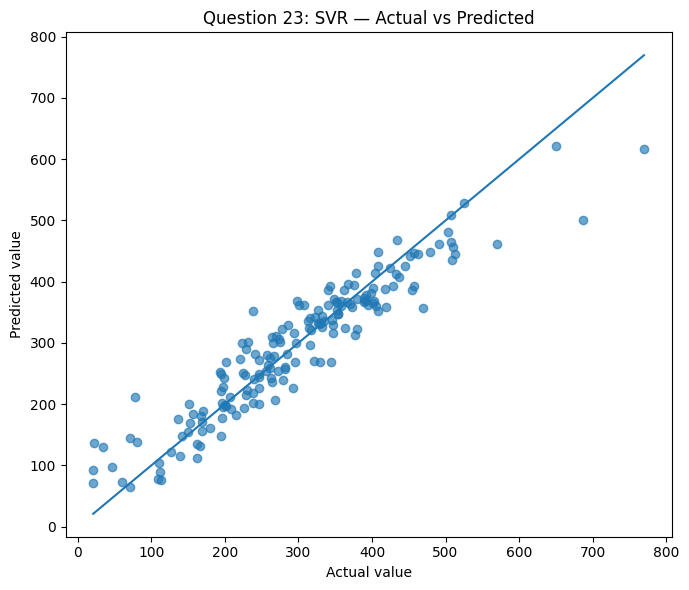

In [4]:
X23, y23 = make_regression(
    n_samples=700, n_features=8, n_informative=7,
    noise=25, random_state=RANDOM_STATE
)
y23 = y23 + 300
X23_train, X23_test, y23_train, y23_test = train_test_split(
    X23, y23, test_size=0.25, random_state=RANDOM_STATE
)
q23_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=100, epsilon=0.1))
])
q23_model.fit(X23_train, y23_train)
q23_pred = q23_model.predict(X23_test)
print(f'Mean Squared Error: {mean_squared_error(y23_test, q23_pred):.4f}')

plt.figure(figsize=(7, 6))
plt.scatter(y23_test, q23_pred, alpha=0.65)
limits = [min(y23_test.min(), q23_pred.min()), max(y23_test.max(), q23_pred.max())]
plt.plot(limits, limits)
plt.xlabel('Actual value')
plt.ylabel('Predicted value')
plt.title('Question 23: SVR — Actual vs Predicted')
plt.tight_layout()
plt.show()

## Question 24: Train a Polynomial-Kernel SVM and visualize the decision boundary
The moons dataset provides a simple nonlinear classification example.

Training accuracy: 0.9767


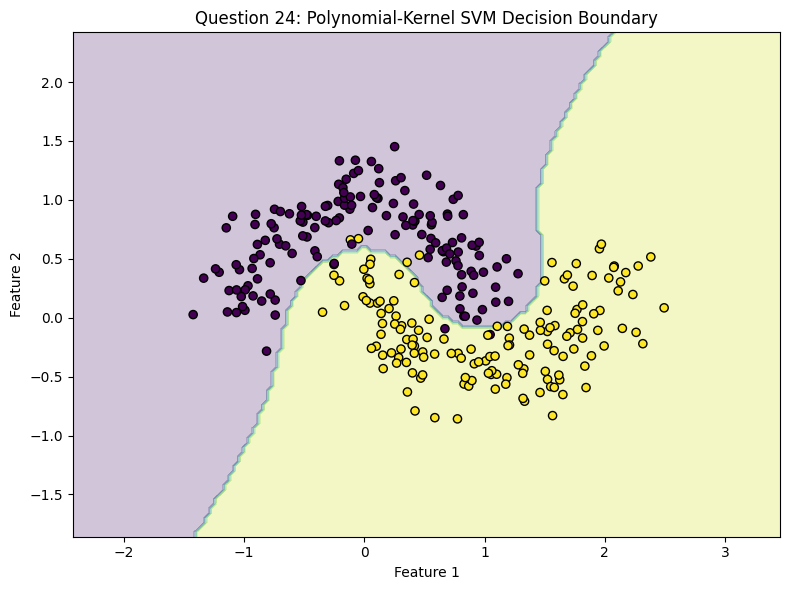

In [5]:
X24, y24 = make_moons(n_samples=300, noise=0.18, random_state=RANDOM_STATE)
q24_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='poly', degree=3, C=3, coef0=1))
])
q24_model.fit(X24, y24)
print(f'Training accuracy: {accuracy_score(y24, q24_model.predict(X24)):.4f}')
plot_decision_boundary(
    q24_model, X24, y24,
    'Question 24: Polynomial-Kernel SVM Decision Boundary'
)

## Question 25: Train Gaussian Naive Bayes on Breast Cancer data and evaluate accuracy

In [6]:
cancer = load_breast_cancer()
X25, y25 = cancer.data, cancer.target
X25_train, X25_test, y25_train, y25_test = train_test_split(
    X25, y25, test_size=0.25, stratify=y25, random_state=RANDOM_STATE
)
q25_model = GaussianNB()
q25_model.fit(X25_train, y25_train)
q25_pred = q25_model.predict(X25_test)
print(f'Accuracy: {accuracy_score(y25_test, q25_pred):.4f}')
print(classification_report(y25_test, q25_pred, target_names=cancer.target_names))

Accuracy: 0.9371
              precision    recall  f1-score   support

   malignant       0.96      0.87      0.91        53
      benign       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143



## Question 26: Train Multinomial Naive Bayes for text classification using 20 Newsgroups
### ⚠️ Offline-safe implementation
This notebook uses a small four-topic text sample that follows the same workflow as 20 Newsgroups: text vectorization followed by Multinomial NB. This avoids download errors in offline environments.

In [7]:
topic_documents = {
    0: [
        'Computer graphics software renders three dimensional images.',
        'The image contains pixels colors and rendering information.',
        'A graphics card accelerates animation and visual processing.',
        'Vector drawing software creates scalable illustrations.',
        'Ray tracing produces realistic light and shadows.',
        'The monitor displays a rendered digital picture.'
    ],
    1: [
        'The baseball pitcher threw a fast ball in the final inning.',
        'The team won the match with a home run.',
        'Batting averages measure a hitter performance.',
        'The catcher received the pitch behind home plate.',
        'The league season includes many baseball games.',
        'The coach changed the batting order.'
    ],
    2: [
        'The spacecraft entered orbit around the planet.',
        'Astronauts conducted an experiment in the space station.',
        'A rocket launched a satellite into space.',
        'The telescope observed a distant galaxy.',
        'The lunar mission studied rocks on the moon.',
        'Scientists calculated the spacecraft trajectory.'
    ],
    3: [
        'The election campaign discussed public policy.',
        'Parliament debated a new government proposal.',
        'Voters selected representatives in the election.',
        'Political parties disagreed about taxation.',
        'The minister announced a policy reform.',
        'The debate focused on law and government.'
    ]
}

docs26, labels26 = [], []
for label, docs in topic_documents.items():
    docs26.extend(docs)
    labels26.extend([label] * len(docs))

X26_train_text, X26_test_text, y26_train, y26_test = train_test_split(
    docs26, labels26, test_size=0.33,
    stratify=labels26, random_state=RANDOM_STATE
)
q26_model = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('nb', MultinomialNB(alpha=1.0))
])
q26_model.fit(X26_train_text, y26_train)
q26_pred = q26_model.predict(X26_test_text)
print(f'Accuracy: {accuracy_score(y26_test, q26_pred):.4f}')

Accuracy: 1.0000


## Question 27: Train SVM with different C values and compare decision boundaries
Small `C` gives stronger regularization; large `C` penalizes training errors more strongly.

C=0.1: accuracy=0.9536


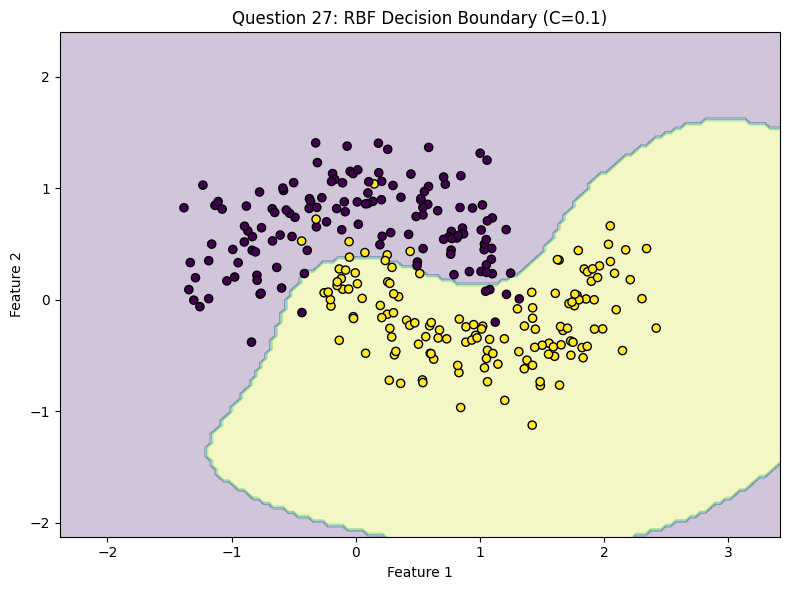

C=1: accuracy=0.9643


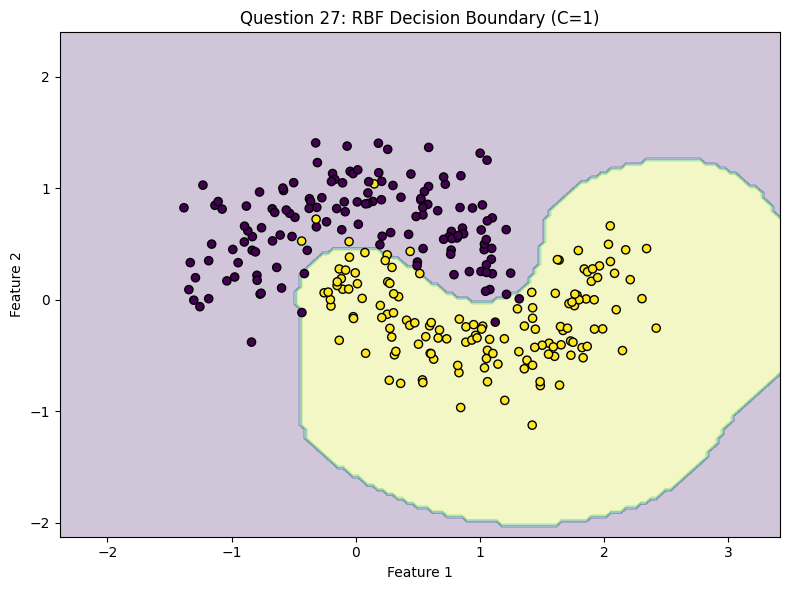

C=100: accuracy=0.9714


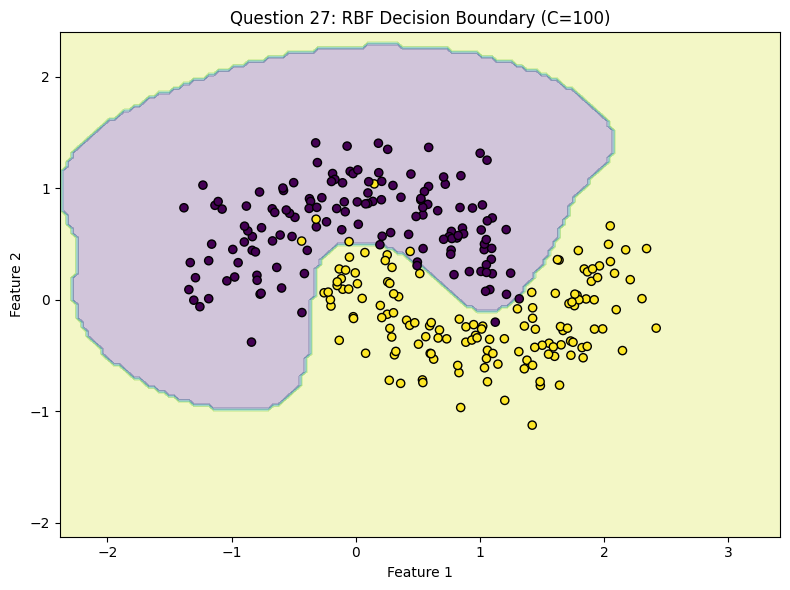

In [8]:
X27, y27 = make_moons(n_samples=280, noise=0.22, random_state=RANDOM_STATE)
for c_value in [0.1, 1, 100]:
    model27 = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=c_value, gamma=1.0))
    ])
    model27.fit(X27, y27)
    print(f'C={c_value}: accuracy={accuracy_score(y27, model27.predict(X27)):.4f}')
    plot_decision_boundary(
        model27, X27, y27,
        f'Question 27: RBF Decision Boundary (C={c_value})'
    )

## Question 28: Train Bernoulli Naive Bayes on binary features
Continuous synthetic features are converted to 0/1 indicators before training.

In [9]:
X28_cont, y28 = make_classification(
    n_samples=700, n_features=12, n_informative=8,
    n_redundant=2, random_state=RANDOM_STATE
)
thresholds28 = np.median(X28_cont, axis=0)
X28 = (X28_cont > thresholds28).astype(int)
X28_train, X28_test, y28_train, y28_test = train_test_split(
    X28, y28, test_size=0.25, stratify=y28, random_state=RANDOM_STATE
)
q28_model = BernoulliNB(alpha=1.0)
q28_model.fit(X28_train, y28_train)
q28_pred = q28_model.predict(X28_test)
print(f'Accuracy: {accuracy_score(y28_test, q28_pred):.4f}')
print('Feature values:', np.unique(X28))

Accuracy: 0.6400
Feature values: [0 1]


## Question 29: Apply feature scaling before SVM and compare with unscaled data

In [10]:
X29, y29 = wine.data, wine.target
X29_train, X29_test, y29_train, y29_test = train_test_split(
    X29, y29, test_size=0.30, stratify=y29, random_state=RANDOM_STATE
)
q29_models = {
    'Unscaled SVM': SVC(kernel='rbf'),
    'Scaled SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf'))
    ])
}
q29_results = []
for name, model in q29_models.items():
    model.fit(X29_train, y29_train)
    q29_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y29_test, model.predict(X29_test))
    })
pd.DataFrame(q29_results).sort_values('Accuracy', ascending=False)

,Model,Accuracy
1,Scaled SVM,0.9815
0,Unscaled SVM,0.6667


## Question 30: Compare Gaussian Naive Bayes before and after smoothing
### ⚠️ Conceptual clarification
Gaussian NB does not use Laplace count smoothing. It uses `var_smoothing`, which stabilizes continuous variance estimates.

In [11]:
X30, y30 = cancer.data, cancer.target
X30_train, X30_test, y30_train, y30_test = train_test_split(
    X30, y30, test_size=0.25, stratify=y30, random_state=RANDOM_STATE
)
q30_results, base30 = [], None
for smoothing in [1e-12, 1e-9, 1e-6, 1e-3]:
    model30 = GaussianNB(var_smoothing=smoothing)
    model30.fit(X30_train, y30_train)
    pred30 = model30.predict(X30_test)
    if base30 is None:
        base30 = pred30.copy()
    q30_results.append({
        'var_smoothing': smoothing,
        'Accuracy': accuracy_score(y30_test, pred30),
        'Predictions changed vs 1e-12': np.sum(pred30 != base30)
    })
pd.DataFrame(q30_results)

,var_smoothing,Accuracy,Predictions changed vs 1e-12
0,1.0000e-12,0.9371,0
1,1.0000e-09,0.9371,2
2,1.0000e-06,0.9231,12
3,1.0000e-03,0.9091,12


## Question 31: Tune SVM hyperparameters using GridSearchCV

In [12]:
X31, y31 = wine.data, wine.target
X31_train, X31_test, y31_train, y31_test = train_test_split(
    X31, y31, test_size=0.25, stratify=y31, random_state=RANDOM_STATE
)
q31_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])
q31_grid = GridSearchCV(
    q31_pipeline,
    {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 0.1],
        'svc__kernel': ['linear', 'rbf']
    },
    cv=3, scoring='accuracy', n_jobs=1
)
q31_grid.fit(X31_train, y31_train)
q31_pred = q31_grid.predict(X31_test)
print('Best parameters:', q31_grid.best_params_)
print(f'Best CV accuracy: {q31_grid.best_score_:.4f}')
print(f'Test accuracy: {accuracy_score(y31_test, q31_pred):.4f}')

Best parameters: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV accuracy: 0.9924
Test accuracy: 0.9556


## Question 32: Apply class weighting on an imbalanced SVM dataset
Raw accuracy can be misleading, so balanced accuracy, minority recall, and minority F1 are included.

In [13]:
X32, y32 = make_classification(
    n_samples=1400, n_features=14, n_informative=8,
    n_redundant=2, weights=[0.95, 0.05],
    class_sep=1.0, random_state=RANDOM_STATE
)
X32_train, X32_test, y32_train, y32_test = train_test_split(
    X32, y32, test_size=0.30, stratify=y32, random_state=RANDOM_STATE
)
q32_models = {
    'Standard SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf'))
    ]),
    'Class-weighted SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', class_weight='balanced'))
    ])
}
q32_results = []
for name, model in q32_models.items():
    model.fit(X32_train, y32_train)
    pred = model.predict(X32_test)
    q32_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y32_test, pred),
        'Balanced Accuracy': balanced_accuracy_score(y32_test, pred),
        'Minority Recall': recall_score(y32_test, pred),
        'Minority F1': f1_score(y32_test, pred)
    })
pd.DataFrame(q32_results)

,Model,Accuracy,Balanced Accuracy,Minority Recall,Minority F1
0,Standard SVM,0.9476,0.5000,0.0000,0.0000
1,Class-weighted SVM,0.9119,0.8247,0.7273,0.4638


## Question 33: Implement Naive Bayes spam detection using email text

In [14]:
emails33 = [
    'Congratulations you won a free cash prize claim now',
    'Exclusive offer buy now and receive a discount',
    'Winner selected click the link to collect reward',
    'Urgent your account won a lottery payment',
    'Free vacation deal available for a limited time',
    'Earn money fast from home guaranteed',
    'Claim your bonus coupon immediately',
    'Lowest price medicine order today',
    'You have been selected for a special reward',
    'Act now to receive free gift cards',
    'Can we meet tomorrow to discuss the project',
    'Please find the class notes attached',
    'Your appointment is confirmed for Monday',
    'The team meeting starts at ten',
    'Happy birthday have a wonderful day',
    'Please review the report before submission',
    'Dinner is ready come home safely',
    'Your library book is due next week',
    'The assignment deadline has been extended',
    'Thank you for helping with the presentation'
]
labels33 = np.array([1] * 10 + [0] * 10)
X33_train, X33_test, y33_train, y33_test = train_test_split(
    emails33, labels33, test_size=0.30,
    stratify=labels33, random_state=RANDOM_STATE
)
q33_model = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('nb', MultinomialNB(alpha=1.0))
])
q33_model.fit(X33_train, y33_train)
q33_pred = q33_model.predict(X33_test)
print(f'Accuracy: {accuracy_score(y33_test, q33_pred):.4f}')
samples33 = ['Free prize available click now', 'Please attend tomorrow project meeting']
for text, pred in zip(samples33, q33_model.predict(samples33)):
    print(f'{text!r} -> {"Spam" if pred == 1 else "Ham"}')

Accuracy: 0.8333
'Free prize available click now' -> Spam
'Please attend tomorrow project meeting' -> Ham


## Question 34: Compare SVM and Gaussian Naive Bayes on the same dataset

In [15]:
X34, y34 = cancer.data, cancer.target
X34_train, X34_test, y34_train, y34_test = train_test_split(
    X34, y34, test_size=0.25, stratify=y34, random_state=RANDOM_STATE
)
q34_models = {
    'RBF SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf'))
    ]),
    'Gaussian NB': GaussianNB()
}
q34_results = []
for name, model in q34_models.items():
    model.fit(X34_train, y34_train)
    pred = model.predict(X34_test)
    q34_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y34_test, pred),
        'Precision': precision_score(y34_test, pred),
        'Recall': recall_score(y34_test, pred),
        'F1-score': f1_score(y34_test, pred)
    })
pd.DataFrame(q34_results).sort_values('Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
0,RBF SVM,0.9790,0.9888,0.9778,0.9832
1,Gaussian NB,0.9371,0.9263,0.9778,0.9514


## Question 35: Perform feature selection before Naive Bayes and compare results

In [16]:
X35, y35 = cancer.data, cancer.target
X35_train, X35_test, y35_train, y35_test = train_test_split(
    X35, y35, test_size=0.25, stratify=y35, random_state=RANDOM_STATE
)
q35_models = {
    'All 30 features': GaussianNB(),
    'Top 10 features': Pipeline([
        ('select', SelectKBest(f_classif, k=10)),
        ('nb', GaussianNB())
    ])
}
q35_results = []
for name, model in q35_models.items():
    model.fit(X35_train, y35_train)
    q35_results.append({
        'Approach': name,
        'Accuracy': accuracy_score(y35_test, model.predict(X35_test))
    })
pd.DataFrame(q35_results)

,Approach,Accuracy
0,All 30 features,0.9371
1,Top 10 features,0.9301


## Question 36: Compare One-vs-Rest and One-vs-One SVM strategies on Wine data

In [17]:
X36, y36 = wine.data, wine.target
X36_train, X36_test, y36_train, y36_test = train_test_split(
    X36, y36, test_size=0.25, stratify=y36, random_state=RANDOM_STATE
)
base36 = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])
q36_models = {
    'One-vs-Rest': OneVsRestClassifier(base36),
    'One-vs-One': OneVsOneClassifier(base36)
}
q36_results = []
for name, model in q36_models.items():
    model.fit(X36_train, y36_train)
    q36_results.append({
        'Strategy': name,
        'Accuracy': accuracy_score(y36_test, model.predict(X36_test))
    })
pd.DataFrame(q36_results)

,Strategy,Accuracy
0,One-vs-Rest,0.9778
1,One-vs-One,0.9556


## Question 37: Compare Linear, Polynomial, and RBF kernels on Breast Cancer data

In [18]:
X37, y37 = cancer.data, cancer.target
X37_train, X37_test, y37_train, y37_test = train_test_split(
    X37, y37, test_size=0.25, stratify=y37, random_state=RANDOM_STATE
)
settings37 = {
    'Linear': {'kernel': 'linear'},
    'Polynomial': {'kernel': 'poly', 'degree': 3, 'coef0': 1},
    'RBF': {'kernel': 'rbf'}
}
q37_results = []
for name, params in settings37.items():
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(**params))
    ])
    model.fit(X37_train, y37_train)
    q37_results.append({
        'Kernel': name,
        'Accuracy': accuracy_score(y37_test, model.predict(X37_test))
    })
q37_results_df = pd.DataFrame(q37_results).sort_values('Accuracy', ascending=False)
q37_results_df

,Kernel,Accuracy
1,Polynomial,0.993
0,Linear,0.986
2,RBF,0.979


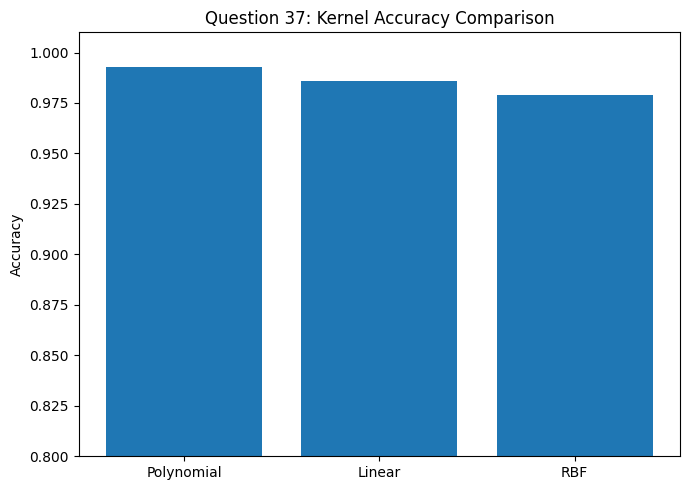

In [19]:
plt.figure(figsize=(7, 5))
plt.bar(q37_results_df['Kernel'], q37_results_df['Accuracy'])
plt.ylim(0.80, 1.01)
plt.ylabel('Accuracy')
plt.title('Question 37: Kernel Accuracy Comparison')
plt.tight_layout()
plt.show()

## Question 38: Use Stratified K-Fold Cross-Validation and compute average accuracy

In [20]:
X38, y38 = cancer.data, cancer.target
q38_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])
q38_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
q38_scores = cross_val_score(q38_model, X38, y38, cv=q38_cv, scoring='accuracy')
print('Fold accuracies:', np.round(q38_scores, 4))
print(f'Average accuracy: {q38_scores.mean():.4f}')
print(f'Standard deviation: {q38_scores.std():.4f}')

Fold accuracies: [0.9912 0.9474 0.9737 0.9912 0.9823]
Average accuracy: 0.9772
Standard deviation: 0.0163


## Question 39: Train Naive Bayes with different prior probabilities

In [21]:
X39, y39 = cancer.data, cancer.target
X39_train, X39_test, y39_train, y39_test = train_test_split(
    X39, y39, test_size=0.25, stratify=y39, random_state=RANDOM_STATE
)
priors39 = {
    'Learned from data': None,
    'Equal priors': [0.5, 0.5],
    'Favor class 0': [0.7, 0.3],
    'Favor class 1': [0.3, 0.7]
}
q39_results = []
for name, priors in priors39.items():
    model = GaussianNB(priors=priors)
    model.fit(X39_train, y39_train)
    pred = model.predict(X39_test)
    q39_results.append({
        'Prior setting': name,
        'Accuracy': accuracy_score(y39_test, pred),
        'Predicted class-1 rate': np.mean(pred == 1)
    })
pd.DataFrame(q39_results)

,Prior setting,Accuracy,Predicted class-1 rate
0,Learned from data,0.9371,0.6643
1,Equal priors,0.9371,0.6503
2,Favor class 0,0.9301,0.6434
3,Favor class 1,0.9441,0.6713


## Question 40: Perform Recursive Feature Elimination before SVM and compare accuracy

In [22]:
X40, y40 = cancer.data, cancer.target
X40_train, X40_test, y40_train, y40_test = train_test_split(
    X40, y40, test_size=0.25, stratify=y40, random_state=RANDOM_STATE
)
q40_models = {
    'All features': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='linear'))
    ]),
    'RFE: 10 features': Pipeline([
        ('scaler', StandardScaler()),
        ('rfe', RFE(
            estimator=SVC(kernel='linear'),
            n_features_to_select=10,
            step=5
        )),
        ('svc', SVC(kernel='linear'))
    ])
}
q40_results = []
for name, model in q40_models.items():
    model.fit(X40_train, y40_train)
    q40_results.append({
        'Approach': name,
        'Accuracy': accuracy_score(y40_test, model.predict(X40_test))
    })
pd.DataFrame(q40_results)

,Approach,Accuracy
0,All features,0.986
1,RFE: 10 features,0.972


## Question 41: Evaluate SVM using Precision, Recall, and F1-Score

In [23]:
X41, y41 = cancer.data, cancer.target
X41_train, X41_test, y41_train, y41_test = train_test_split(
    X41, y41, test_size=0.25, stratify=y41, random_state=RANDOM_STATE
)
q41_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])
q41_model.fit(X41_train, y41_train)
q41_pred = q41_model.predict(X41_test)
pd.DataFrame([{
    'Precision': precision_score(y41_test, q41_pred),
    'Recall': recall_score(y41_test, q41_pred),
    'F1-score': f1_score(y41_test, q41_pred)
}])

,Precision,Recall,F1-score
0,0.9888,0.9778,0.9832


## Question 42: Train Naive Bayes and evaluate Log Loss

In [24]:
X42, y42 = cancer.data, cancer.target
X42_train, X42_test, y42_train, y42_test = train_test_split(
    X42, y42, test_size=0.25, stratify=y42, random_state=RANDOM_STATE
)
q42_model = GaussianNB()
q42_model.fit(X42_train, y42_train)
q42_prob = q42_model.predict_proba(X42_test)
q42_pred = q42_model.predict(X42_test)
print(f'Accuracy: {accuracy_score(y42_test, q42_pred):.4f}')
print(f'Log Loss: {log_loss(y42_test, q42_prob):.4f}')

Accuracy: 0.9371
Log Loss: 0.3671


## Question 43: Train SVM and visualize the Confusion Matrix
A heatmap-style confusion matrix is produced using scikit-learn and Matplotlib.

[[52  1]
 [ 2 88]]


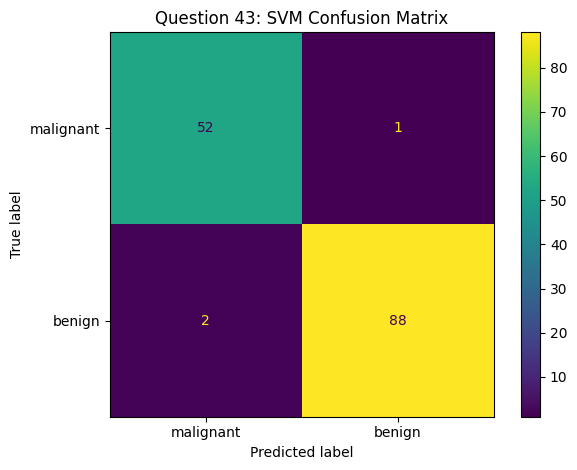

In [25]:
X43, y43 = cancer.data, cancer.target
X43_train, X43_test, y43_train, y43_test = train_test_split(
    X43, y43, test_size=0.25, stratify=y43, random_state=RANDOM_STATE
)
q43_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])
q43_model.fit(X43_train, y43_train)
q43_pred = q43_model.predict(X43_test)
print(confusion_matrix(y43_test, q43_pred))
ConfusionMatrixDisplay.from_predictions(
    y43_test, q43_pred,
    display_labels=cancer.target_names,
    values_format='d'
)
plt.title('Question 43: SVM Confusion Matrix')
plt.tight_layout()
plt.show()

## Question 44: Train SVR and evaluate Mean Absolute Error instead of MSE

In [26]:
X44, y44 = make_regression(
    n_samples=700, n_features=8, n_informative=7,
    noise=25, random_state=RANDOM_STATE
)
y44 = y44 + 300
X44_train, X44_test, y44_train, y44_test = train_test_split(
    X44, y44, test_size=0.25, random_state=RANDOM_STATE
)
q44_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=100, epsilon=0.1))
])
q44_model.fit(X44_train, y44_train)
q44_pred = q44_model.predict(X44_test)
print(f'Mean Absolute Error: {mean_absolute_error(y44_test, q44_pred):.4f}')

Mean Absolute Error: 32.3214


## Question 45: Train Naive Bayes and evaluate ROC-AUC

ROC-AUC score: 0.9893


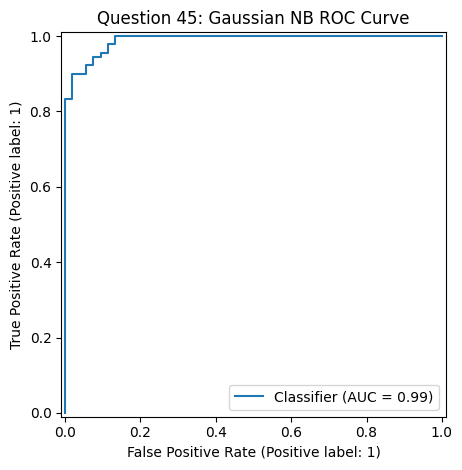

In [27]:
X45, y45 = cancer.data, cancer.target
X45_train, X45_test, y45_train, y45_test = train_test_split(
    X45, y45, test_size=0.25, stratify=y45, random_state=RANDOM_STATE
)
q45_model = GaussianNB()
q45_model.fit(X45_train, y45_train)
q45_prob = q45_model.predict_proba(X45_test)[:, 1]
q45_auc = roc_auc_score(y45_test, q45_prob)
print(f'ROC-AUC score: {q45_auc:.4f}')
RocCurveDisplay.from_predictions(y45_test, q45_prob)
plt.title('Question 45: Gaussian NB ROC Curve')
plt.tight_layout()
plt.show()

## Question 46: Train SVM and visualize the Precision–Recall Curve

Average Precision: 0.9981


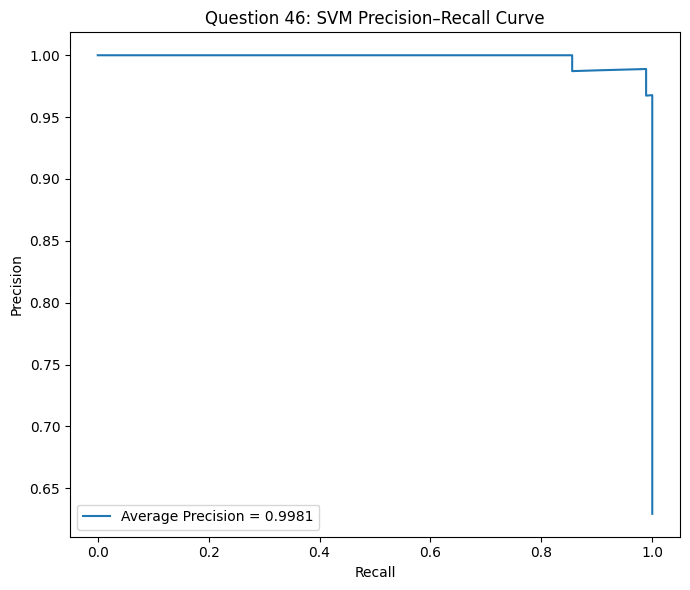

In [28]:
X46, y46 = cancer.data, cancer.target
X46_train, X46_test, y46_train, y46_test = train_test_split(
    X46, y46, test_size=0.25, stratify=y46, random_state=RANDOM_STATE
)
q46_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])
q46_model.fit(X46_train, y46_train)
q46_scores = q46_model.decision_function(X46_test)
precision46, recall46, _ = precision_recall_curve(y46_test, q46_scores)
ap46 = average_precision_score(y46_test, q46_scores)
print(f'Average Precision: {ap46:.4f}')
plt.figure(figsize=(7, 6))
plt.plot(recall46, precision46, label=f'Average Precision = {ap46:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Question 46: SVM Precision–Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

# ✅ Final Summary

## Support Vector Machine
- Maximizes the margin between classes.
- Uses support vectors to define the decision boundary.
- Supports linear and nonlinear kernels.
- Usually requires scaling and tuning.
- `C` controls regularization; `gamma` controls local influence.

## Naive Bayes
- Applies Bayes' theorem with conditional independence.
- Gaussian NB handles continuous features.
- Multinomial NB handles counts.
- Bernoulli NB handles binary indicators.
- Smoothing prevents unstable or zero probabilities.

## Practical conclusion
No model is universally best. Compare models with suitable metrics, cross-validation, class balance, feature type, interpretability, and computational cost.